In [2]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

from sklearn.model_selection import cross_val_score
from sklearn.tree import plot_tree

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [3]:
model = joblib.load("D:/EVELATE_LAS_INTERSHIP/Healthcare_NoShow_Prediction/models/decision_tree.pkl")

print(model)

DecisionTreeClassifier(max_depth=6, random_state=42)


In [4]:
df = pd.read_csv("D:/EVELATE_LAS_INTERSHIP/Healthcare_NoShow_Prediction/data/eda_cleaned_appointments.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (110522, 18)


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show,WaitingDays,Weekday,Month,AgeGroup
0,2.987250e+13,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,0,0,Friday,4,Senior
1,5.589978e+14,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,0,0,Friday,4,Adult
2,4.262962e+12,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,0,0,Friday,4,Senior
3,8.679512e+11,5642828,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0,0,0,0,0,0,Friday,4,Child
4,8.841186e+12,5642494,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,0,0,0,0,0,Friday,4,Adult


In [31]:
df = df.drop(columns=[
    "PatientId",
    "AppointmentID",
    "ScheduledDay",
    "AppointmentDay"
])

print(df.columns.tolist())

['Gender', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show', 'WaitingDays', 'Weekday', 'Month', 'AgeGroup']


In [32]:
label_encoders = {}

categorical_columns = [
    "Gender",
    "Neighbourhood",
    "Weekday",
    "AgeGroup"
]

for col in categorical_columns:

    encoder = LabelEncoder()

    df[col] = encoder.fit_transform(df[col].astype(str))

    label_encoders[col] = encoder

print("Categorical Encoding Completed")

df.head()

Categorical Encoding Completed


,Gender,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show,WaitingDays,Weekday,Month,AgeGroup
0,0,62,27,0,1,0,0,0,0,0,0,0,4,2
1,1,56,27,0,0,0,0,0,0,0,0,0,4,0
2,0,62,35,0,0,0,0,0,0,0,0,0,4,2
3,0,8,46,0,0,0,0,0,0,0,0,0,4,1
4,0,56,27,0,1,1,0,0,0,0,0,0,4,0


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [23]:
X_test

,Gender,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,WaitingDays,Weekday,Month,AgeGroup
32636,F,32,MARIA ORTIZ,0,0,0,0,0,1,28,Tuesday,5,Young Adult
58886,F,60,CONQUISTA,0,1,1,0,0,1,4,Tuesday,5,Adult
107933,F,55,RESISTÊNCIA,0,0,0,0,0,0,5,Wednesday,6,Adult
79677,M,64,CENTRO,0,0,0,0,0,1,12,Tuesday,5,Senior
62674,F,34,JARDIM CAMBURI,0,0,0,0,0,0,0,Tuesday,5,Young Adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...
57913,F,33,NOVA PALESTINA,0,0,0,0,0,1,17,Thursday,5,Young Adult
5399,M,40,REDENÇÃO,0,0,0,0,0,0,2,Wednesday,5,Adult
33966,F,1,SÃO BENEDITO,0,0,0,0,0,0,0,Tuesday,5,Child
33258,F,38,SANTA MARTHA,0,0,0,0,0,0,32,Friday,5,Adult


In [34]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[0 0 0 0 0 0 0 0 0 0]


In [35]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.7978737842117168


In [36]:
precision = precision_score(y_test, y_pred)

print("Precision :", precision)

Precision : 0.35294117647058826


In [37]:
recall = recall_score(y_test, y_pred)

print("Recall :", recall)

Recall : 0.0013443871835088505


In [38]:
f1 = f1_score(y_test, y_pred)

print("F1 Score :", f1)

F1 Score : 0.0026785714285714286


In [39]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      1.00      0.89     17642
           1       0.35      0.00      0.00      4463

    accuracy                           0.80     22105
   macro avg       0.58      0.50      0.45     22105
weighted avg       0.71      0.80      0.71     22105



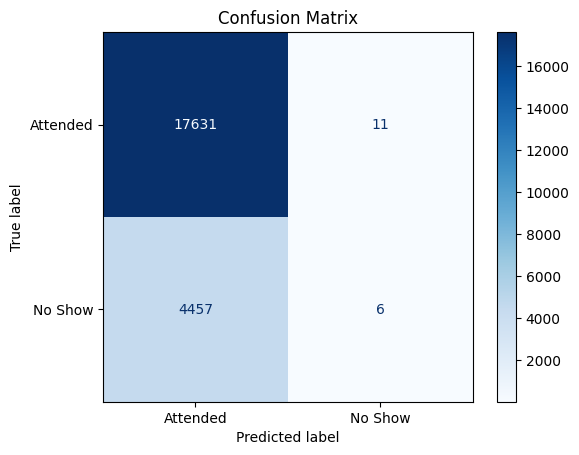

In [40]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Attended", "No Show"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

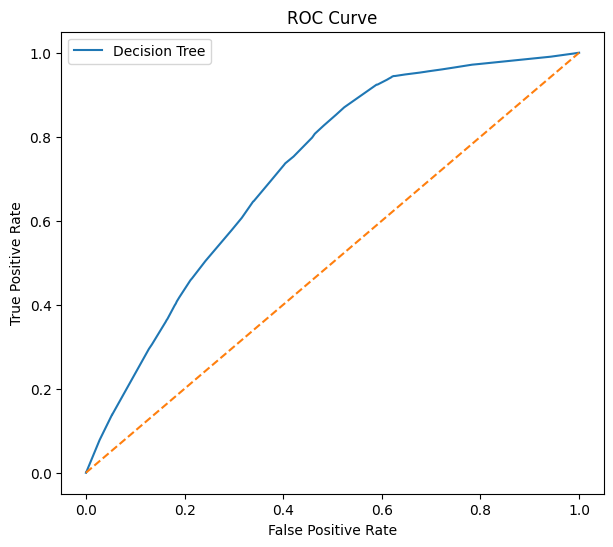

In [41]:
y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, label="Decision Tree")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [42]:
auc = roc_auc_score(y_test, y_prob)

print("AUC Score :", auc)

AUC Score : 0.7199045214830283


In [43]:
scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores")

print(scores)

print()

print("Average Accuracy :", scores.mean())

Cross Validation Scores
[0.79769283 0.79669758 0.7910333  0.79795512 0.79646218]

Average Accuracy : 0.7959682013173235


In [44]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
9,WaitingDays,0.798185
1,Age,0.142044
8,SMS_received,0.024830
2,Neighbourhood,0.009271
0,Gender,0.006222
10,Weekday,0.005496
12,AgeGroup,0.003879
3,Scholarship,0.003755
6,Alcoholism,0.002662
5,Diabetes,0.001929


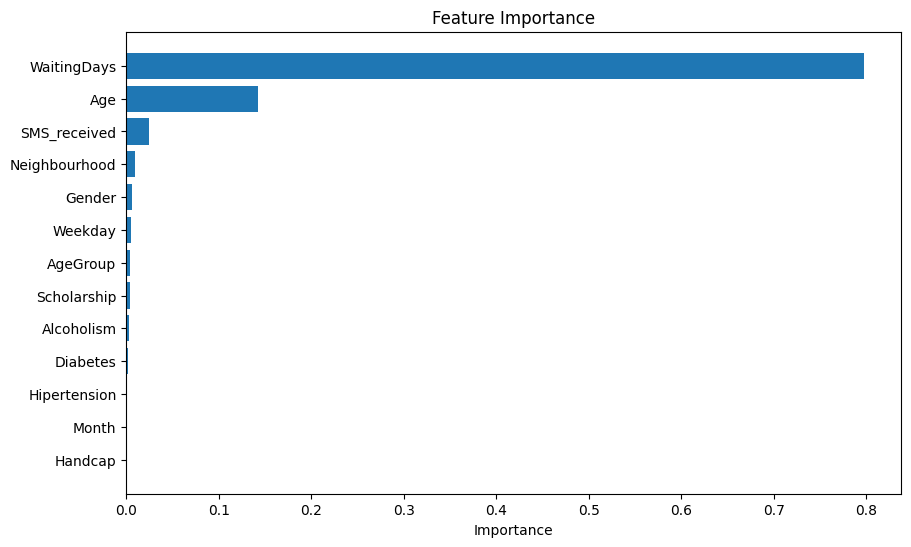

In [45]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Feature Importance")

plt.xlabel("Importance")

plt.show()

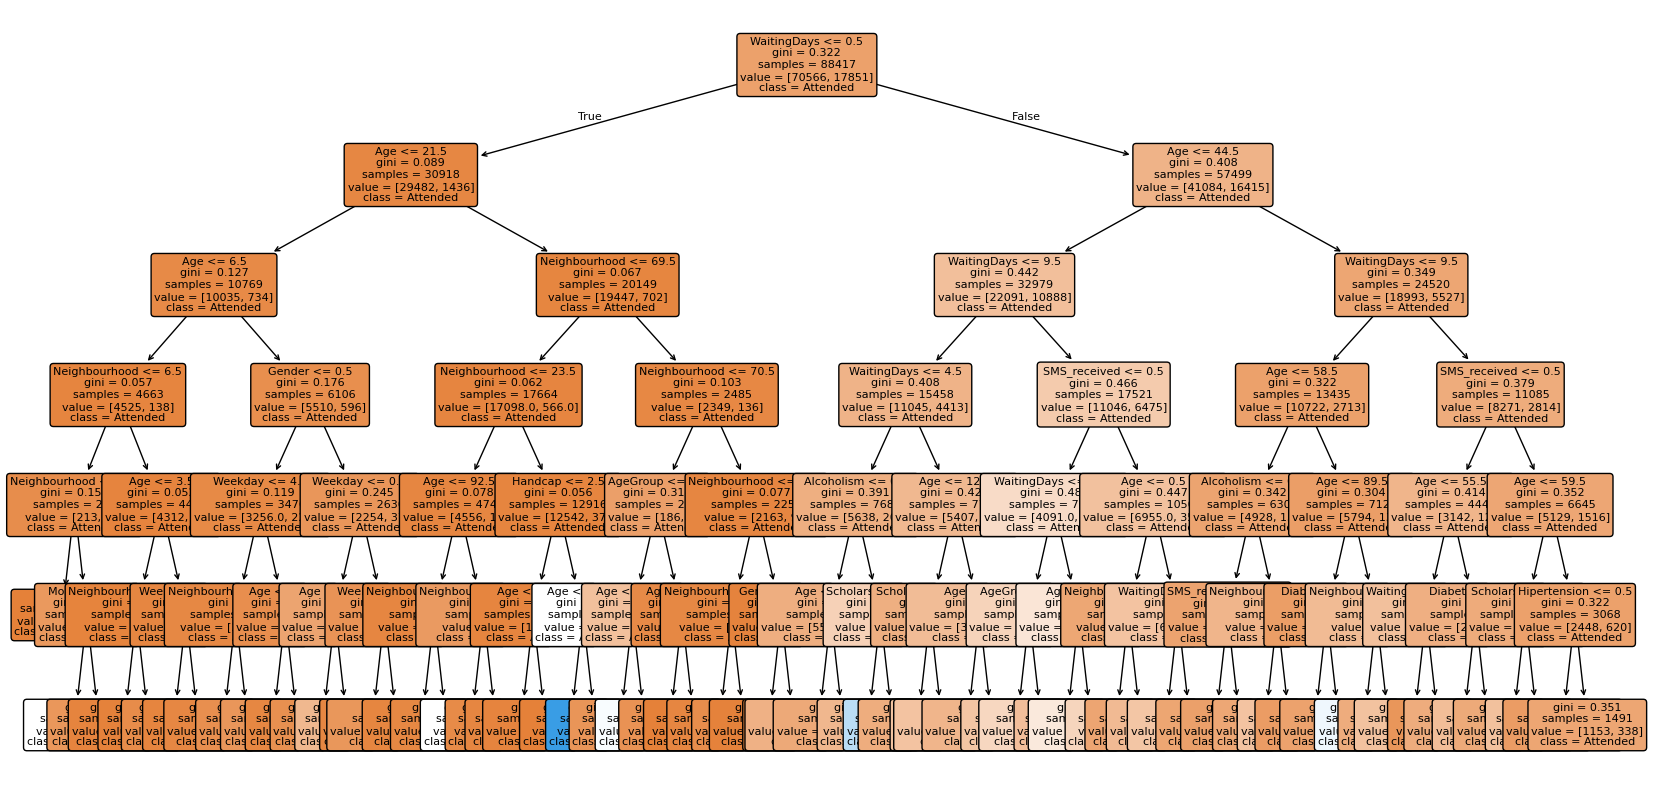

In [46]:
plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Attended","No Show"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

In [47]:
comparison = pd.DataFrame({

    "Actual":y_test.values,

    "Predicted":y_pred

})

comparison.head(20)

,Actual,Predicted
0,1,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,1,0
8,0,0
9,0,0


In [48]:
comparison.to_csv(
    "predictions.csv",
    index=False
)

print("Prediction File Saved Successfully!")

Prediction File Saved Successfully!


In [49]:
print("="*60)

print("Business Insights")

print("="*60)

print("1. Focus on patients with longer waiting days.")

print("2. Send SMS reminders before appointments.")

print("3. Identify high-risk neighbourhoods.")

print("4. Schedule high-risk patients earlier.")

print("5. Use the prediction model to reduce missed appointments.")

print("="*60)

Business Insights
1. Focus on patients with longer waiting days.
2. Send SMS reminders before appointments.
3. Identify high-risk neighbourhoods.
4. Schedule high-risk patients earlier.
5. Use the prediction model to reduce missed appointments.


In [50]:
print("="*60)

print("Healthcare Appointment No-Show Prediction")

print("="*60)

print(f"Accuracy : {accuracy:.4f}")

print(f"Precision : {precision:.4f}")

print(f"Recall : {recall:.4f}")

print(f"F1 Score : {f1:.4f}")

print(f"AUC Score : {auc:.4f}")

print(f"Cross Validation Accuracy : {scores.mean():.4f}")

print("="*60)

Healthcare Appointment No-Show Prediction
Accuracy : 0.7979
Precision : 0.3529
Recall : 0.0013
F1 Score : 0.0027
AUC Score : 0.7199
Cross Validation Accuracy : 0.7960
